<a href="https://colab.research.google.com/github/jnanaprasanna57/ML_Project/blob/main/ML_Codealpha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


*Random Forest Evaluation*
Accuracy: 1.00

Confusion Matrix:
 [[ 30   0]
 [  0 170]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00       170

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



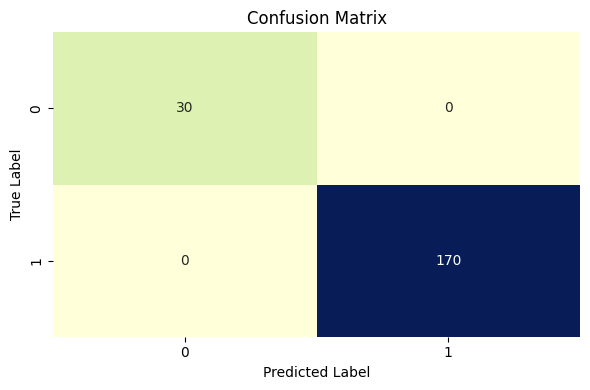

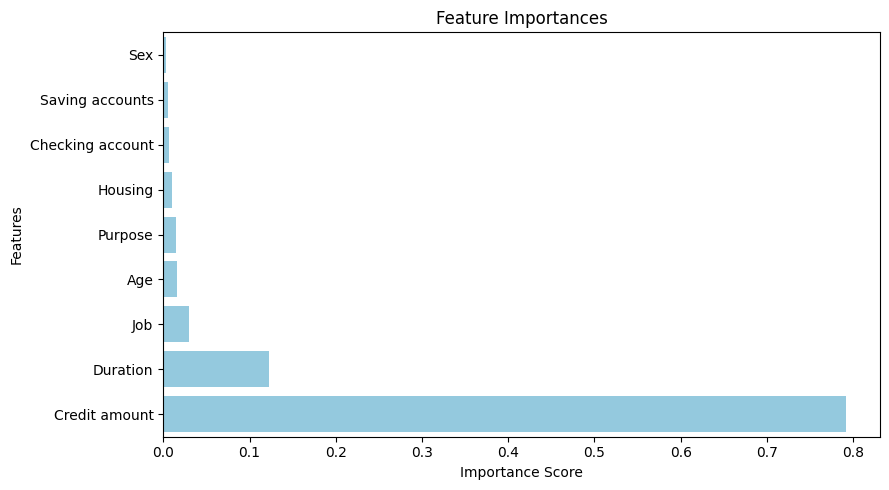

In [1]:
# Credit Scoring Model (TASK-1)

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/german_credit_data.csv")
df.drop(columns=["Unnamed: 0"], inplace=True)
df["Saving accounts"] = df["Saving accounts"].fillna("no_info")
df["Checking account"] = df["Checking account"].fillna("no_info")
le = LabelEncoder()
categorical_features = ["Sex", "Housing", "Saving accounts", "Checking account", "Purpose"]
df[categorical_features] = df[categorical_features].apply(le.fit_transform)
df["Risk"] = df["Credit amount"].apply(lambda amount: "good" if amount <= 5000 else "bad")
df["Risk"] = le.fit_transform(df["Risk"])
X = df.drop("Risk", axis=1)
y = df["Risk"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, zero_division=0)
print("\n*Random Forest Evaluation*")
print(f"Accuracy: {accuracy:.2f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="YlGnBu", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()
importances = pd.Series(model.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values()
plt.figure(figsize=(9,5))
sns.barplot(x=importances_sorted.values, y=importances_sorted.index, color="skyblue")
plt.title("Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

Accuracy: 0.98
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       159
           1       1.00      0.96      0.98       149

    accuracy                           0.98       308
   macro avg       0.98      0.98      0.98       308
weighted avg       0.98      0.98      0.98       308



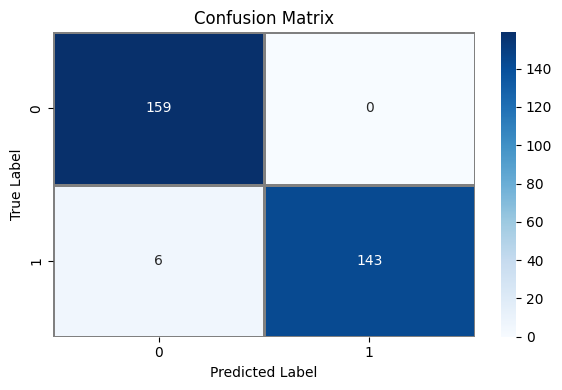

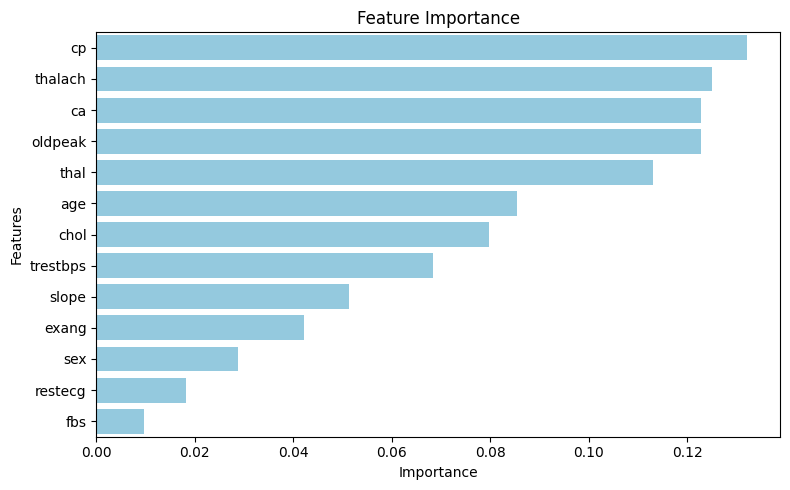

In [2]:
#Disease Prediction from Medical Data(TASK-4)

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('/content/disease.csv')
df = df.dropna()
for col in df.select_dtypes(include=['object', 'category']).columns:
    df[col] = LabelEncoder().fit_transform(df[col])
if df['target'].dtype == 'object':
    df['target'] = LabelEncoder().fit_transform(df['target'])
X = df.drop('target', axis=1)
y = df['target']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print(classification_report(y_test, y_pred))
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", linewidths=1, linecolor='gray')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Calculate feature importance
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False) # For better visualization

plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importance, y=feature_importance.index, color='skyblue', legend=False)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

Epoch 1/15


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 317ms/step - accuracy: 0.0579 - loss: 3.7079 - val_accuracy: 0.0000e+00 - val_loss: 3.7796
Epoch 2/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.0370 - loss: 3.6258 - val_accuracy: 0.0000e+00 - val_loss: 3.8558
Epoch 3/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.0721 - loss: 3.5646 - val_accuracy: 0.0000e+00 - val_loss: 4.0185
Epoch 4/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.0683 - loss: 3.4940 - val_accuracy: 0.0000e+00 - val_loss: 4.2121
Epoch 5/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.0683 - loss: 3.4394 - val_accuracy: 0.0000e+00 - val_loss: 4.2929
Epoch 6/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.1177 - loss: 3.4443 - val_accuracy: 0.0714 - val_loss: 4.2818
Epoch 7/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.0826 - loss: 3.4039 - val_accuracy: 0.0714 - val_loss: 4.3256
Epoch 8/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.1385 - loss: 3.3760 - val_accuracy: 0.0714 - val_lo

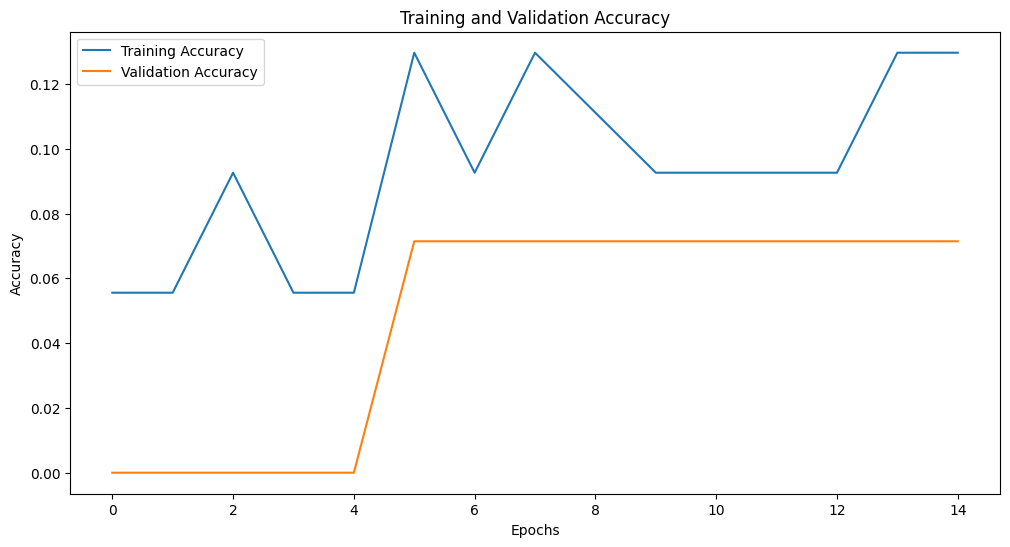

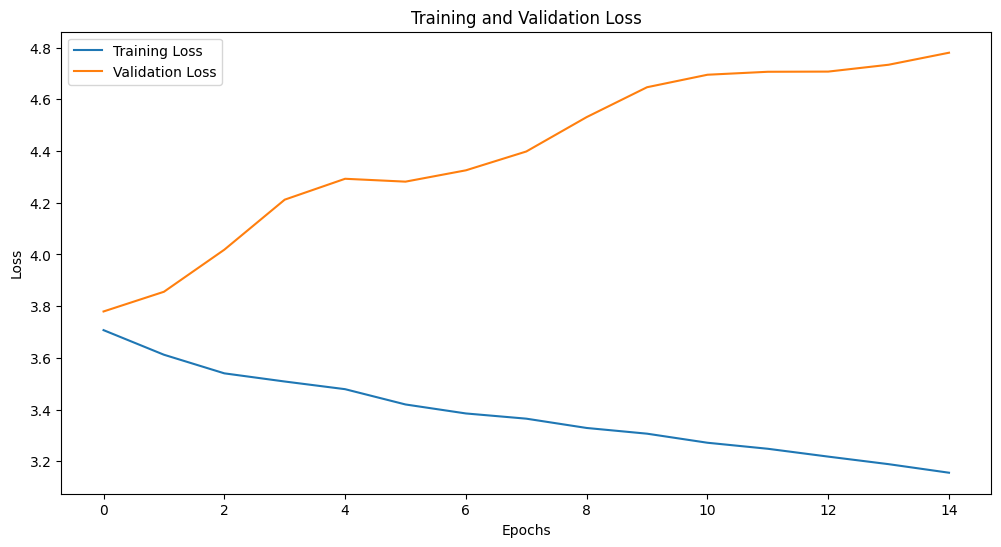

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.0714 - loss: 4.7805

Test accuracy: 0.0714


In [4]:
#Handwritten character Recognition (Task-3)

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Load metadata
labels_df = pd.read_csv('/content/labels.csv', header=2)
labels = labels_df['Class'].values
devnagari_chars = labels_df['Devanagari Label'].values

# Convert labels to strings
labels = labels.astype(str)

# Use LabelEncoder to convert string labels to numerical values
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

# Image preprocessing (assuming you have image data in a 'images' directory)
# Replace this with actual image loading logic matching your dataset structure
# Example: Load 32x32 grayscale images, normalize pixel values
def load_images():
    # This is a placeholder - implement based on your image data structure
    num_samples = len(labels)
    return np.random.rand(num_samples, 32, 32, 1)  # Random dummy data

images = load_images()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    images, labels_encoded, test_size=0.2, random_state=42
)

# CNN Model Architecture
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(np.unique(labels_encoded)), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Training
history = model.fit(X_train, y_train,
                    epochs=15,
                    validation_data=(X_test, y_test))

# Plotting training and validation accuracy
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plotting training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluation
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'\nTest accuracy: {test_acc:.4f}')
